In [55]:
import pandas as pd
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

import mediapipe as mp

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

import pickle

from tensorflow.keras import layers, models, callbacks

# DATA PREPARATION

In [13]:
FINAL_DATA_PATH = "../dataset/csv/ds_cctv_v1.csv"
df = pd.read_csv(FINAL_DATA_PATH)
df.head()

,class,x1,y1,z1,v1,x2,y2,z2,v2,x3,...,y74,z74,v74,x75,y75,z75,v75,face_d15,face_s15,hand_s15
0,Nutup Muka,0.469739,0.578589,-0.127777,0.993265,0.440848,0.569411,-0.112306,0.994901,0.439771,...,0.711073,-0.029289,0.473242,0.495799,0.711073,-0.029289,0.473242,0.0,1.0,1.0
1,Nutup Muka,0.445407,0.614889,0.017926,0.995142,0.429321,0.619205,-0.039531,0.995156,0.433832,...,0.570589,0.175774,0.242573,0.472730,0.570589,0.175774,0.242573,0.0,0.0,0.0
2,Nutup Muka,0.445444,0.615121,-0.014786,0.997897,0.430551,0.620001,-0.072877,0.998852,0.432003,...,0.573695,0.211646,0.227217,0.469184,0.573695,0.211646,0.227217,0.0,0.0,0.0
3,Nutup Muka,0.445540,0.614011,-0.004351,0.998440,0.430781,0.619389,-0.064572,0.999206,0.432518,...,0.512440,0.060926,0.288927,0.469143,0.512440,0.060926,0.288927,0.0,0.0,0.0
4,Nutup Muka,0.457175,0.567999,-0.048380,0.995301,0.430904,0.577609,-0.091666,0.986735,0.437979,...,0.554917,0.211508,0.696219,0.514506,0.554917,0.211508,0.696219,0.0,0.0,0.0


## Splitting and Labeling

Splitting the data from csv, and then label each of the output using `LabelEncoder`

In [14]:
X = df.drop(['class'], axis=1)
y = df['class']

Checking the value of each class in the label

In [15]:
y.value_counts()

class
Nutup Muka    30
Diam          30
Celinguk      30
Name: count, dtype: int64

## Labeling on y

In [17]:
encoder = LabelEncoder()
y_enc = encoder.fit_transform(y)

In [21]:
y_enc[:5], y[:5]

(array([2, 2, 2, 2, 2]),
 0    Nutup Muka
 1    Nutup Muka
 2    Nutup Muka
 3    Nutup Muka
 4    Nutup Muka
 Name: class, dtype: object)

In [23]:
for i, cls in enumerate(encoder.classes_):
    print(f"{cls} : {i}")

Celinguk : 0
Diam : 1
Nutup Muka : 2


## Data Splitting

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, train_size=.8, stratify=y_enc)
print(f"""
Total data X_train : {len(X_train)}
Total data X_test : {len(X_test)}
Total data y_train : {len(y_train)}
Total data y_test : {len(y_test)}
""")


Total data X_train : 72
Total data X_test : 18
Total data y_train : 72
Total data y_test : 18



# MODEL PREPARATION & TRAINING (SKLEARN)

In [48]:
all_models = {
    "knn": make_pipeline(StandardScaler(), KNeighborsClassifier()),
    "dtc": make_pipeline(StandardScaler(), DecisionTreeClassifier()),
    "rfc": make_pipeline(StandardScaler(), RandomForestClassifier()),
    "svc": make_pipeline(StandardScaler(), SVC())
}

fitted_models = {}

model_scores = {}

In [49]:
for name, pipeline in all_models.items():
    print(f"Currently, training {name}")
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline
    model_scores[name] = pipeline.score(X_test, y_test)

Currently, training knn
Currently, training dtc
Currently, training rfc
Currently, training svc


In [50]:
for name, score in model_scores.items():
    print(f"{name} : {score}")

knn : 0.8333333333333334
dtc : 0.7222222222222222
rfc : 0.8333333333333334
svc : 0.7777777777777778


In [51]:
with open("model/best_sklearn_model.pkl", "wb") as f:
    pickle.dump(fitted_models['rfc'], f) # <<<< SAVE BEST MODEL

In [56]:
results = []

for name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    results.append({
        "Model": name.upper(),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1-Score": f1_score(y_test, y_pred, average="weighted")
    })

df_results = pd.DataFrame(results).set_index("Model")
df_results

,Accuracy,Precision,Recall,F1-Score
Model,,,,
KNN,0.833333,0.850000,0.833333,0.831169
DTC,0.722222,0.779762,0.722222,0.716728
RFC,0.833333,0.838095,0.833333,0.832168
SVC,0.777778,0.822222,0.777778,0.775758


# MODEL PREPARATION & TRAINING (TENSORFLOW)

In [36]:
X_train.shape

(72, 345)

In [38]:
MODEL_INPUT_SHAPE = (X_train.shape[1],)
MODEL_TOTAL_OUTPUT = len(np.unique(y_train))
BEST_MODEL_PATH = "Model/best_nn_model.h5"

In [39]:
print(MODEL_INPUT_SHAPE, MODEL_TOTAL_OUTPUT)

(345,) 3


In [44]:
checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",                      
)

earlystop_cb = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
)

In [45]:
nn_model = models.Sequential([
    layers.Dense(16, input_shape=MODEL_INPUT_SHAPE, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(np.unique(y_train)), activation='softmax'),
])

nn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

d:\Project Coding\Research\suspicious_detection_cctv\venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
history = nn_model.fit(
    X_train, y_train, 
    epochs=30,
    validation_split=0.2,
    callbacks=[checkpoint_cb, earlystop_cb])

Epoch 1/30
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 808ms/step - accuracy: 0.1875 - loss: 1.2043

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - accuracy: 0.2613 - loss: 1.1663 - val_accuracy: 0.4667 - val_loss: 1.0476
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.2926 - loss: 1.0946 - val_accuracy: 0.4667 - val_loss: 1.0412
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3264 - loss: 1.0929 - val_accuracy: 0.4667 - val_loss: 1.0481
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.2939 - loss: 1.1035 - val_accuracy: 0.4000 - val_loss: 1.0594
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.3798 - loss: 1.0721 - val_accuracy: 0.4667 - val_loss: 1.0615
Epoch 6/30
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5000 - loss: 1.0628

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4708 - loss: 1.0654 - val_accuracy: 0.5333 - val_loss: 1.0646
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5020 - loss: 1.0531 - val_accuracy: 0.4000 - val_loss: 1.0612
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4720 - loss: 1.0410 - val_accuracy: 0.4667 - val_loss: 1.0606
Epoch 9/30
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6250 - loss: 1.0469

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5826 - loss: 1.0469 - val_accuracy: 0.6667 - val_loss: 1.0616
Epoch 10/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5956 - loss: 1.0408 - val_accuracy: 0.6000 - val_loss: 1.0522
Epoch 11/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6502 - loss: 1.0194 - val_accuracy: 0.6667 - val_loss: 1.0427
Epoch 12/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6944 - loss: 1.0150 - val_accuracy: 0.6667 - val_loss: 1.0357
Epoch 13/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7049 - loss: 0.9754 - val_accuracy: 0.6667 - val_loss: 1.0362
Epoch 14/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5735 - loss: 0.9575 - val_accuracy: 0.5333 - val_loss: 1.0307


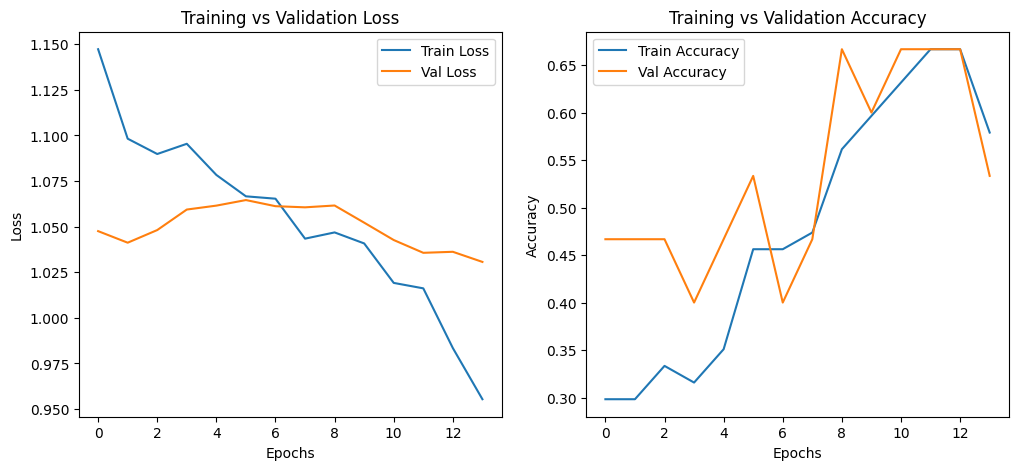

In [47]:
hist = history.history

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist['loss'], label='Train Loss')
plt.plot(hist['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist['accuracy'], label='Train Accuracy')
plt.plot(hist['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()